# PDE Model Reconstruction: POD-SVD, POD-rSVD, POD-DEIM, and POD-rSVD-DEIM

This notebook implements the PDE experiments with a consistent **offline / online** evaluation.

We compare:

- **POD-SVD**: POD basis computed with deterministic SVD;
- **POD-rSVD**: POD basis computed with randomized SVD;
- **POD-DEIM**: nonlinear DEIM basis computed with deterministic SVD;
- **POD-rSVD-DEIM**: nonlinear DEIM basis computed with randomized SVD.

For both POD and POD-DEIM we use the same logic:

1. the basis is built only from training snapshots;
2. the **offline error** is measured on the training snapshots;
3. the **online/test error** is measured on snapshots not used to build the basis.

The heatmap sensitivity plots have been removed. The notebook produces two line plots for each experiment:

- POD Allen--Cahn: offline and online error;
- POD-DEIM Allen--Cahn: offline and online error;
- POD elliptic: offline and online error;
- POD-DEIM elliptic: offline and online error.

All saved figures are exported at the end exactly as in the original notebook.


## 1. Imports and global settings

The notebook is designed for Google Colab and uses only standard scientific Python packages.
No external data files are required.

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import time
import os
import re
import zipfile
from dataclasses import dataclass

try:
    from sklearn.utils.extmath import randomized_svd
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

np.random.seed(42)

# SVD backend choices.
# "svds" computes only the requested factors; "svd" computes the dense SVD.
SVD_MODE = "svds"
RSVD_INNER_SVD_MODE = "svd"

# Repeat each timed basis construction and report average execution time.
N_EXPERIMENT_REPEATS = 10

# Thesis-quality plotting defaults.
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 18,
    "axes.linewidth": 1.1,
    "lines.linewidth": 2.4,
    "lines.markersize": 7,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

FIGURE_DIR = "thesis_figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

# Clean old exported figures so the final ZIP contains only the plots generated
# by this offline/online notebook, and not heatmaps from previous runs.
for file in os.listdir(FIGURE_DIR):
    if file.endswith((".pdf", ".png")):
        os.remove(os.path.join(FIGURE_DIR, file))


## 2. Utility functions

This section defines:

- a 2D finite-difference Laplacian with homogeneous Dirichlet boundary conditions;
- classical POD basis construction;
- randomized POD basis construction;
- DEIM interpolation point selection;
- relative error and timing utilities.

For all experiments, the solution is represented only at interior grid points.
If the spatial grid has `n` interior points per direction, the full-order dimension is:

\[
N=n^2.
\]

In [2]:
def make_laplacian_2d(n):
    """
    Construct the 2D finite-difference Laplacian on (0,1)^2
    with homogeneous Dirichlet boundary conditions.

    Parameters
    ----------
    n : int
        Number of interior grid points per spatial direction.

    Returns
    -------
    L : scipy.sparse.csr_matrix
        Sparse matrix approximating the Laplacian operator Delta.
    h : float
        Spatial grid size.
    X, Y : ndarray
        Meshgrid of interior points.
    """
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1.0 - h, n)
    X, Y = np.meshgrid(x, x, indexing="ij")

    e = np.ones(n)
    T = sp.diags([e, -2.0 * e, e], [-1, 0, 1], shape=(n, n), format="csr") / h**2
    I = sp.eye(n, format="csr")
    L = sp.kron(I, T) + sp.kron(T, I)
    return L.tocsr(), h, X, Y


def relative_fro_error(A, Ahat):
    """Relative Frobenius norm error."""
    return la.norm(A - Ahat, ord="fro") / la.norm(A, ord="fro")


def relative_l2_error(u, uhat):
    """Relative Euclidean norm error."""
    return la.norm(u - uhat) / la.norm(u)


def _leading_svd(A, k, mode="svd"):
    """Return leading k singular triplets using the selected backend."""
    min_dim = min(A.shape)

    if mode == "svds" and k < min_dim:
        U, s, Vt = spla.svds(A, k=k, which="LM")
        order = np.argsort(s)[::-1]
        return U[:, order], s[order], Vt[order, :]

    U, s, Vt = la.svd(A, full_matrices=False)
    return U[:, :k], s[:k], Vt[:k, :]


def pod_basis_svd(S, r, mode="svd"):
    """
    Construct a POD basis from a snapshot matrix using classical SVD.

    S has shape (N, Ns), where N is the full-order dimension
    and Ns is the number of snapshots.
    """
    t0 = time.perf_counter()
    U, s, Vt = _leading_svd(S, r, mode=mode)
    elapsed = time.perf_counter() - t0
    Phi = U[:, :r]
    return Phi, s, elapsed


def pod_basis_rsvd(S, r, oversampling=10, n_iter=1, random_state=42, inner_svd_mode="svd"):
    """
    Construct a POD basis from a snapshot matrix using randomized SVD.
    """
    rng = np.random.default_rng(random_state)
    n_columns = S.shape[1]
    ell = min(r + oversampling, min(S.shape))

    t0 = time.perf_counter()

    Omega = rng.standard_normal(size=(n_columns, ell))
    Y = S @ Omega

    for _ in range(n_iter):
        Y = S @ (S.T @ Y)

    Q, _ = la.qr(Y, mode="economic")
    B = Q.T @ S
    U_tilde, s, Vt = _leading_svd(B, r, mode=inner_svd_mode)
    U = Q @ U_tilde

    elapsed = time.perf_counter() - t0
    return U[:, :r], s, elapsed


def projection_reconstruction_error(S, Phi):
    """
    Compute the relative reconstruction error of the snapshot matrix
    using the orthogonal projection onto span(Phi).
    """
    Shat = Phi @ (Phi.T @ S)
    return relative_fro_error(S, Shat)


def deim(U):
    """
    Classical DEIM index selection.

    Given a nonlinear basis U = [u_1, ..., u_m], select interpolation indices
    following the greedy DEIM algorithm.
    """
    n, m = U.shape
    indices = []

    p0 = np.argmax(np.abs(U[:, 0]))
    indices.append(p0)

    for j in range(1, m):
        U_prev = U[:, :j]
        p_prev = np.array(indices)

        c = la.solve(U_prev[p_prev, :], U[p_prev, j])
        r = U[:, j] - U_prev @ c
        pj = np.argmax(np.abs(r))
        indices.append(pj)

    return np.array(indices, dtype=int)


def deim_approximation(f, U_f, indices):
    """
    Evaluate the DEIM approximation of a nonlinear vector f.

    f approximately equals U_f (P^T U_f)^(-1) P^T f.
    """
    PTUf = U_f[indices, :]
    coeff = la.solve(PTUf, f[indices])
    return U_f @ coeff


def time_function(func, n_repeats=5):
    """Measure average wall-clock execution time of a function."""
    times = []
    out = None
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        out = func()
        times.append(time.perf_counter() - t0)
    return out, np.mean(times), np.std(times)


def effective_rank_from_snapshots(S, requested_rank):
    """
    Return a safe rank for SVD/rSVD computations.
    The maximum numerical rank cannot exceed min(S.shape).
    """
    return int(max(1, min(requested_rank, min(S.shape))))


def pod_basis(
    S,
    r,
    method="svd",
    oversampling=10,
    n_iter=1,
    random_state=42,
    svd_mode=None,
    rsvd_inner_svd_mode=None,
    n_repeats=1,
):
    """
    Unified POD basis constructor.

    Parameters
    ----------
    S : ndarray
        Snapshot matrix.
    r : int
        Requested reduced dimension.
    method : {'svd', 'rsvd'}
        Basis construction method.
    oversampling : int
        Oversampling parameter for rSVD.
    n_iter : int
        Number of power iterations for rSVD.
    random_state : int
        Random seed for reproducibility.
    svd_mode : {'svd', 'svds'}
        SVD backend for deterministic POD.
    rsvd_inner_svd_mode : {'svd', 'svds'}
        SVD backend for the small projected matrix in rSVD.
    n_repeats : int
        Number of repeated timings to average.
    """
    svd_mode = SVD_MODE if svd_mode is None else svd_mode
    rsvd_inner_svd_mode = RSVD_INNER_SVD_MODE if rsvd_inner_svd_mode is None else rsvd_inner_svd_mode

    if svd_mode not in {"svd", "svds"}:
        raise ValueError("svd_mode must be either 'svd' or 'svds'.")
    if rsvd_inner_svd_mode not in {"svd", "svds"}:
        raise ValueError("rsvd_inner_svd_mode must be either 'svd' or 'svds'.")
    if n_repeats < 1:
        raise ValueError("n_repeats must be at least 1.")

    r_eff = effective_rank_from_snapshots(S, r)
    times = []
    Phi = s = info = None

    for repeat in range(n_repeats):
        if method == "svd":
            Phi, s, elapsed = pod_basis_svd(S, r_eff, mode=svd_mode)
            info = {"r_eff": r_eff, "p_eff": None}
        elif method == "rsvd":
            max_p = max(0, min(S.shape) - r_eff)
            p_eff = int(min(max(0, oversampling), max_p))
            Phi, s, elapsed = pod_basis_rsvd(
                S,
                r_eff,
                oversampling=p_eff,
                n_iter=n_iter,
                random_state=random_state,
                inner_svd_mode=rsvd_inner_svd_mode,
            )
            info = {"r_eff": r_eff, "p_eff": p_eff}
        else:
            raise ValueError("method must be either 'svd' or 'rsvd'")

        times.append(elapsed)

    info["time_std"] = float(np.std(times))
    return Phi, s, float(np.mean(times)), info


def deim_analysis(
    F_train,
    S_test,
    nonlinear_function,
    m_values,
    basis_method="svd",
    oversampling=10,
    n_iter=1,
    random_state=42,
    n_repeats=5,
    n_basis_repeats=None,
    svd_mode=None,
    rsvd_inner_svd_mode=None,
):
    """
    Build a DEIM basis either with classical SVD or randomized SVD and
    evaluate the nonlinear approximation error and timing on test snapshots.

    Parameters
    ----------
    F_train : ndarray
        Nonlinear snapshot matrix used to build the DEIM basis.
    S_test : ndarray
        State snapshots used to evaluate the nonlinear function.
    nonlinear_function : callable
        Function taking a state vector and returning the nonlinear vector.
    m_values : list[int]
        DEIM basis dimensions.
    basis_method : {'svd', 'rsvd'}
        Method used to compute the nonlinear basis U_f.
    oversampling : int
        rSVD oversampling parameter when basis_method='rsvd'.
    n_iter : int
        rSVD power iterations when basis_method='rsvd'.
    random_state : int
        Random seed.
    n_repeats : int
        Number of repetitions used for wall-clock timing of evaluations.
    n_basis_repeats : int
        Number of repetitions used for wall-clock timing of basis construction.
    """
    results = []
    if n_basis_repeats is None:
        n_basis_repeats = N_EXPERIMENT_REPEATS

    for m in m_values:
        U_f, sf, build_time, info = pod_basis(
            F_train,
            m,
            method=basis_method,
            oversampling=oversampling,
            n_iter=n_iter,
            random_state=random_state,
            svd_mode=svd_mode,
            rsvd_inner_svd_mode=rsvd_inner_svd_mode,
            n_repeats=n_basis_repeats,
        )
        m_eff = info["r_eff"]
        indices = deim(U_f)

        errors = []
        full_times = []
        deim_times = []

        for j in range(S_test.shape[1]):
            y = S_test[:, j]
            f_true = nonlinear_function(y)

            _, full_t, _ = time_function(lambda: nonlinear_function(y), n_repeats=n_repeats)
            f_deim, deim_t, _ = time_function(lambda: deim_approximation(f_true, U_f, indices), n_repeats=n_repeats)

            denom = la.norm(f_true)
            if denom == 0:
                errors.append(0.0)
            else:
                errors.append(la.norm(f_true - f_deim) / denom)
            full_times.append(full_t)
            deim_times.append(deim_t)

        label = "POD-DEIM" if basis_method == "svd" else f"p={oversampling}, q={n_iter}"
        results.append({
            "method": label,
            "basis_method": basis_method,
            "m": m_eff,
            "p": None if basis_method == "svd" else oversampling,
            "p_eff": info["p_eff"],
            "q": None if basis_method == "svd" else n_iter,
            "basis_time": float(build_time),
            "basis_time_std": info["time_std"],
            "mean_error": float(np.mean(errors)),
            "std_error": float(np.std(errors)),
            "full_time": float(np.mean(full_times)),
            "deim_time": float(np.mean(deim_times)),
            "speedup": float(np.mean(full_times) / np.mean(deim_times)) if np.mean(deim_times) > 0 else np.inf,
            "n_deim_points": int(len(indices)),
        })

    return results


def plot_deim_comparison(results, title_prefix):
    """
    Plot DEIM and rSVD-DEIM nonlinear approximation error, basis construction time,
    and evaluation time.
    """
    methods = []
    for row in results:
        if row["method"] not in methods:
            methods.append(row["method"])

    fig, ax = plt.subplots(figsize=(9, 5))
    for method in methods:
        rows = [x for x in results if x["method"] == method]
        ax.errorbar(
            [x["m"] for x in rows],
            [x["mean_error"] for x in rows],
            yerr=[x["std_error"] for x in rows],
            marker="o",
            linewidth=2,
            capsize=4,
            label=method,
        )
    ax.set_yscale("log")
    ax.set_xlabel("DEIM basis dimension m")
    ax.set_ylabel("Relative nonlinear approximation error")
    ax.set_title(f"{title_prefix}: DEIM vs rSVD-DEIM error")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for method in methods:
        rows = [x for x in results if x["method"] == method]
        ax.plot(
            [x["m"] for x in rows],
            [x["basis_time"] for x in rows],
            marker="o",
            linewidth=2,
            label=method,
        )
    ax.set_xlabel("DEIM basis dimension m")
    ax.set_ylabel("Basis construction time [s]")
    ax.set_title(f"{title_prefix}: nonlinear basis construction time")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    # full nonlinear evaluation is identical for all methods; plot once
    first_method_rows = [x for x in results if x["method"] == methods[0]]
    ax.plot(
        [x["m"] for x in first_method_rows],
        [x["full_time"] for x in first_method_rows],
        marker="o",
        linewidth=2,
        label="Full nonlinear evaluation",
    )
    for method in methods:
        rows = [x for x in results if x["method"] == method]
        ax.plot(
            [x["m"] for x in rows],
            [x["deim_time"] for x in rows],
            marker="o",
            linewidth=2,
            label=f"{method} evaluation",
        )
    ax.set_xlabel("DEIM basis dimension m")
    ax.set_ylabel("Average evaluation time [s]")
    ax.set_title(f"{title_prefix}: nonlinear evaluation time")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    plt.show()


# Part A: Allen-Cahn equation

We consider

$$
y_t - \alpha \Delta y - \mu(y-y^3)=0,
$$

which can be written as

$$
y_t = \alpha \Delta y + \mu(y-y^3).
$$

The experiment uses a semi-implicit finite-difference scheme:

$$
(I - \Delta t \alpha L)y^{n+1}
=
y^n + \Delta t \mu \left(y^n-(y^n)^3\right),
$$

where \(L\) is the discrete Laplacian.

This is not meant to be the most sophisticated solver for Allen-Cahn dynamics.
Its purpose is to generate representative nonlinear PDE snapshots for POD and POD-DEIM analysis.

## 3. Allen-Cahn full-order model

In [3]:
@dataclass
class AllenCahnConfig:
    n: int = 256
    alpha: float = 0.1
    mu: float = 11.0
    T: float = 5.0
    dt: float = 0.005
    snapshot_stride: int = 5


def allen_cahn_initial_condition(X, Y):
    """
    Initial condition from the lab exercise:
    y0(x) = 0.1 sin(pi x1) sin(pi x2).
    """
    return 0.1 * np.sin(np.pi * X) * np.sin(np.pi * Y)


def solve_allen_cahn(config):
    """
    Solve the Allen--Cahn equation and collect solution snapshots
    and nonlinear snapshots f(y)=mu(y-y^3).
    """
    L, h, X, Y = make_laplacian_2d(config.n)
    N = config.n**2
    I = sp.eye(N, format="csr")

    A = I - config.dt * config.alpha * L
    solver = spla.factorized(A.tocsc())

    y = allen_cahn_initial_condition(X, Y).reshape(-1)

    n_steps = int(config.T / config.dt)
    snapshots = []
    nonlinear_snapshots = []
    times = []

    t0 = time.perf_counter()
    for step in range(n_steps + 1):
        if step % config.snapshot_stride == 0:
            snapshots.append(y.copy())
            nonlinear_snapshots.append(config.mu * (y - y**3))
            times.append(step * config.dt)

        rhs = y + config.dt * config.mu * (y - y**3)
        y = solver(rhs)

    elapsed = time.perf_counter() - t0

    S = np.column_stack(snapshots)
    F = np.column_stack(nonlinear_snapshots)

    return {
        "S": S,
        "F": F,
        "times": np.array(times),
        "elapsed": elapsed,
        "grid": (X, Y),
        "config": config,
    }


ac_config = AllenCahnConfig()
ac_data = solve_allen_cahn(ac_config)

S_ac = ac_data["S"]
F_ac = ac_data["F"]

print("Allen-Cahn snapshot matrix shape:", S_ac.shape)
print("Allen-Cahn nonlinear snapshot matrix shape:", F_ac.shape)
print(f"Full-order simulation time: {ac_data['elapsed']:.3f} s")

Allen-Cahn snapshot matrix shape: (65536, 201)
Allen-Cahn nonlinear snapshot matrix shape: (65536, 201)
Full-order simulation time: 33.812 s


## 5. POD and rSVD-POD basis comparison for Allen--Cahn

We construct reduced bases from the Allen--Cahn snapshot matrix using:

- classical SVD;
- randomized SVD with different oversampling values \(p\);
- randomized SVD with different power iteration values \(q\).

For each reduced rank \(r\), we compute the projection reconstruction error:

$$
E_r =
\frac{\|S-\Phi_r\Phi_r^T S\|_F}{\|S\|_F}.
$$

The goal is to separate the influence of **oversampling** from the influence of **power iterations**. Larger \(p\) samples a wider random subspace, while larger \(q\) amplifies dominant singular directions before the final SVD. This is especially useful when the singular values decay slowly.


In [4]:
# Reduced ranks to test: same grid as the original notebook
r_values = [2, 4, 6, 8, 10, 15, 20]

# Oversampling and power-iteration grids: same as the original notebook
oversampling_values = [0, 5, 10, 20]
power_iteration_values = [0, 1, 2]

# Train/test split for POD.
# The basis is built only from S_ac_train.
# Offline error: reconstruction of S_ac_train.
# Online/test error: reconstruction of S_ac_test, not used to build the basis.
split_ac = int(0.7 * S_ac.shape[1])
S_ac_train = S_ac[:, :split_ac]
S_ac_test = S_ac[:, split_ac:]
F_ac_train = F_ac[:, :split_ac]
F_ac_test = F_ac[:, split_ac:]

ac_results = []

for r in r_values:
    # -------------------------------------------------------------------------
    # Deterministic POD-SVD baseline
    # -------------------------------------------------------------------------
    Phi, s, build_time, info = pod_basis(
        S_ac_train,
        r,
        method="svd",
        svd_mode=SVD_MODE,
        n_repeats=N_EXPERIMENT_REPEATS,
    )

    offline_err = projection_reconstruction_error(S_ac_train, Phi)
    online_err = projection_reconstruction_error(S_ac_test, Phi)

    ac_results.append({
        "method": "POD-SVD",
        "r": info["r_eff"],
        "p": None,
        "p_eff": None,
        "q": None,
        "offline_error": offline_err,
        "online_error": online_err,
        # kept for backward compatibility in tables
        "error": online_err,
        "time": build_time,
        "time_std": info["time_std"],
    })

    # -------------------------------------------------------------------------
    # Randomized POD bases for every p, q pair
    # -------------------------------------------------------------------------
    for q in power_iteration_values:
        for p in oversampling_values:
            Phi_r, s_r, build_time_r, info = pod_basis(
                S_ac_train,
                r,
                method="rsvd",
                oversampling=p,
                n_iter=q,
                random_state=42,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
                n_repeats=N_EXPERIMENT_REPEATS,
            )

            offline_err_r = projection_reconstruction_error(S_ac_train, Phi_r)
            online_err_r = projection_reconstruction_error(S_ac_test, Phi_r)

            ac_results.append({
                "method": "POD-rSVD",
                "r": info["r_eff"],
                "p": p,
                "p_eff": info["p_eff"],
                "q": q,
                "offline_error": offline_err_r,
                "online_error": online_err_r,
                # kept for backward compatibility in tables
                "error": online_err_r,
                "time": build_time_r,
                "time_std": info["time_std"],
            })

for row in ac_results[:12]:
    print(row)

print("Each reported POD basis time is averaged over", N_EXPERIMENT_REPEATS, "runs.")


{'method': 'POD-SVD', 'r': 2, 'p': None, 'p_eff': None, 'q': None, 'offline_error': np.float64(0.00289724490804399), 'online_error': np.float64(0.000515709185613475), 'error': np.float64(0.000515709185613475), 'time': 2.603429670000014, 'time_std': 0.39748166333292856}
{'method': 'POD-rSVD', 'r': 2, 'p': 0, 'p_eff': 0, 'q': 0, 'offline_error': np.float64(0.007485962505544497), 'online_error': np.float64(0.0059945937663587285), 'error': np.float64(0.0059945937663587285), 'time': 0.03398554909997529, 'time_std': 0.0072789125170184855}
{'method': 'POD-rSVD', 'r': 2, 'p': 5, 'p_eff': 5, 'q': 0, 'offline_error': np.float64(0.0028972449184311725), 'online_error': np.float64(0.0005157091871263001), 'error': np.float64(0.0005157091871263001), 'time': 0.1027698757999815, 'time_std': 0.04259320824025246}
{'method': 'POD-rSVD', 'r': 2, 'p': 10, 'p_eff': 10, 'q': 0, 'offline_error': np.float64(0.0028972449080440286), 'online_error': np.float64(0.0005157091856134458), 'error': np.float64(0.00051570

Saved: thesis_figures/allen_cahn_pod_offline_error.pdf
Saved: thesis_figures/allen_cahn_pod_offline_error.png


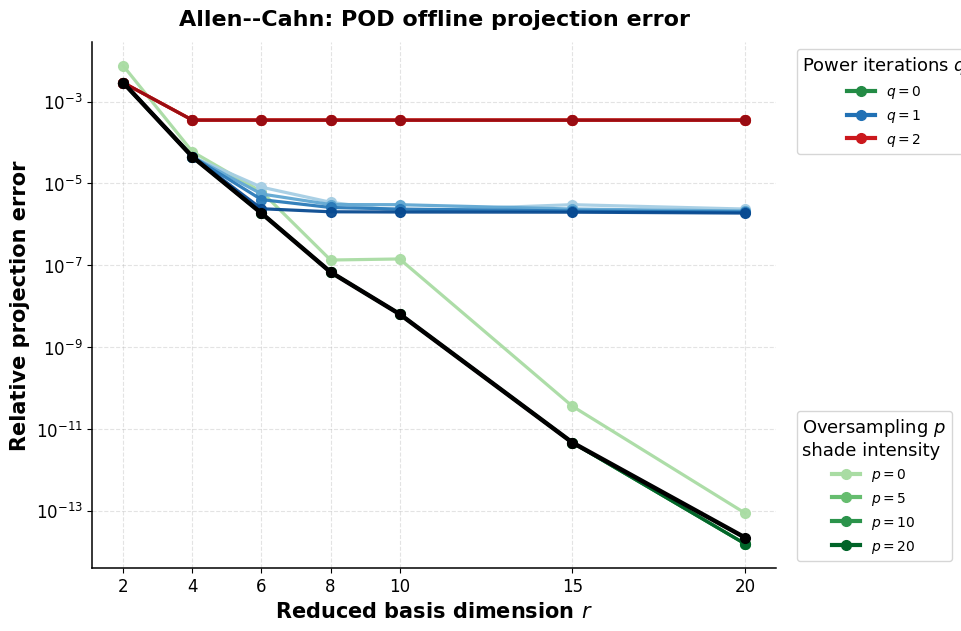

Saved: thesis_figures/allen_cahn_pod_online_error.pdf
Saved: thesis_figures/allen_cahn_pod_online_error.png


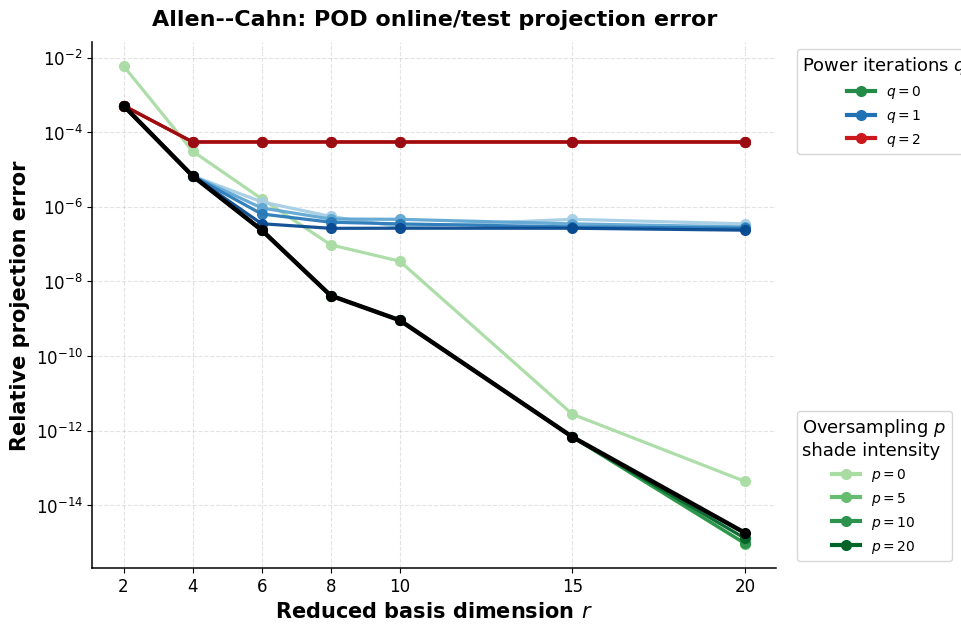

Saved: thesis_figures/allen_cahn_pod_basis_time.pdf
Saved: thesis_figures/allen_cahn_pod_basis_time.png


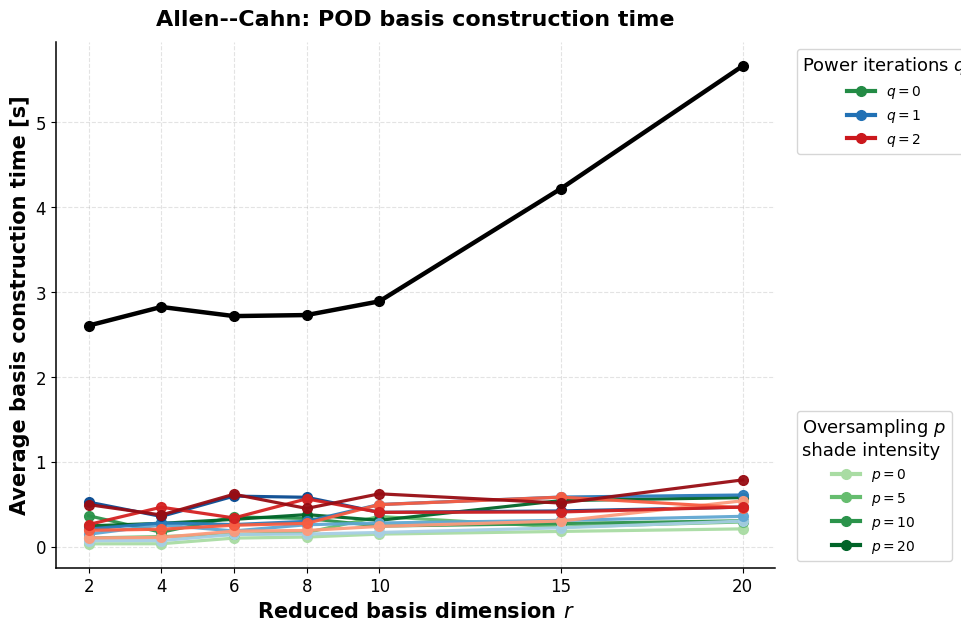

In [5]:
# -----------------------------------------------------------------------------
# Thesis-quality plotting utilities
# -----------------------------------------------------------------------------
# Same graphic convention as the original notebook:
#   q = 0 -> green gradient
#   q = 1 -> blue gradient
#   q = 2 -> red gradient
# Different p values are represented by different shades inside the same q family.

Q_COLORMAPS = {
    0: plt.cm.Greens,
    1: plt.cm.Blues,
    2: plt.cm.Reds,
    3: plt.cm.Purples,
}

Q_BASE_COLORS = {
    0: "#238b45",
    1: "#2171b5",
    2: "#cb181d",
    3: "#6a3d9a",
}

RSVD_MARKER = "o"
RSVD_LINESTYLE = "-"
RSVD_LINEWIDTH = 2.3

from matplotlib.ticker import FixedLocator


def set_discrete_xticks(ax, values):
    values = sorted(set(int(v) for v in values))
    ax.xaxis.set_major_locator(FixedLocator(values))
    ax.set_xticklabels([str(v) for v in values])


def _safe_name(text):
    text = text.lower().replace("--", "_").replace(" ", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:120]


def save_thesis_figure(fig, name):
    """Save each figure both as PDF and PNG for LaTeX and quick inspection."""
    pdf_path = os.path.join(FIGURE_DIR, f"{name}.pdf")
    png_path = os.path.join(FIGURE_DIR, f"{name}.png")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def _style_for_pq(p, q, all_p_values):
    all_p_values = sorted(all_p_values)
    p_index = all_p_values.index(p)
    if len(all_p_values) == 1:
        shade = 0.75
    else:
        shade = 0.35 + 0.55 * (p_index / (len(all_p_values) - 1))
    cmap = Q_COLORMAPS.get(q, Q_COLORMAPS[3])
    color = cmap(shade)
    return color, RSVD_MARKER, RSVD_LINESTYLE


def _add_pq_legend(ax, p_values, q_values):
    q_handles = [
        mlines.Line2D(
            [], [],
            color=Q_BASE_COLORS.get(q, Q_BASE_COLORS[3]),
            marker=RSVD_MARKER,
            linestyle=RSVD_LINESTYLE,
            linewidth=3.0,
            label=rf"$q={q}$",
        )
        for q in sorted(q_values)
    ]

    p_values = sorted(p_values)
    reference_q = sorted(q_values)[0] if q_values else 0
    p_handles = []
    for p in p_values:
        color, marker, linestyle = _style_for_pq(p, reference_q, p_values)
        p_handles.append(
            mlines.Line2D(
                [], [],
                color=color,
                marker=marker,
                linestyle=linestyle,
                linewidth=3.0,
                label=rf"$p={p}$",
            )
        )

    leg1 = ax.legend(
        handles=q_handles,
        title="Power iterations $q$",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=True,
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=p_handles,
        title="Oversampling $p$\nshade intensity",
        loc="lower left",
        bbox_to_anchor=(1.02, 0.00),
        frameon=True,
    )


def _finish_axis(ax, xlabel, ylabel, title, logy=False):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=12)
    if logy:
        ax.set_yscale("log")
    ax.grid(True, which="both" if logy else "major", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_pod_metric(results, metric, title, filename=None):
    """Line plot for either offline or online POD projection error."""
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    svd_rows = sorted([x for x in results if x["method"] == "POD-SVD"], key=lambda x: x["r"])
    rsvd_rows = [x for x in results if x["method"] == "POD-rSVD"]

    ax.plot(
        [x["r"] for x in svd_rows],
        [x[metric] for x in svd_rows],
        marker="o",
        label="POD-SVD",
        linewidth=3.2,
        color="black",
        zorder=10,
    )

    p_values = sorted(set(x["p"] for x in rsvd_rows)) if rsvd_rows else []
    q_values = sorted(set(x["q"] for x in rsvd_rows)) if rsvd_rows else []

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["r"],
            )
            if not rows:
                continue
            color, marker, linestyle = _style_for_pq(p, q, p_values)
            ax.plot(
                [x["r"] for x in rows],
                [x[metric] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
                label=rf"$p={p}, q={q}$",
            )

    _finish_axis(
        ax,
        "Reduced basis dimension $r$",
        "Relative projection error",
        title,
        logy=True,
    )

    x_values = sorted(set(x["r"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)
    if p_values and q_values:
        _add_pq_legend(ax, p_values, q_values)

    if filename is None:
        filename = _safe_name(title)
    save_thesis_figure(fig, filename)
    plt.show()


def plot_deim_metric(results, metric, title, filename=None):
    """Line plot for either offline or online POD-DEIM nonlinear approximation error."""
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    svd_rows = sorted([x for x in results if x.get("basis_method") == "svd"], key=lambda x: x["m"])
    rsvd_rows = [x for x in results if x.get("basis_method") == "rsvd"]

    if svd_rows:
        ax.plot(
            [x["m"] for x in svd_rows],
            [x[metric] for x in svd_rows],
            marker="o",
            linewidth=3.2,
            color="black",
            label="POD-DEIM",
            zorder=10,
        )

    p_values = sorted(set(x["p"] for x in rsvd_rows)) if rsvd_rows else []
    q_values = sorted(set(x["q"] for x in rsvd_rows)) if rsvd_rows else []

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["m"],
            )
            if not rows:
                continue
            color, marker, linestyle = _style_for_pq(p, q, p_values)
            ax.plot(
                [x["m"] for x in rows],
                [x[metric] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
                label=rf"$p={p}, q={q}$",
            )

    _finish_axis(
        ax,
        "DEIM basis dimension $m$",
        "Relative nonlinear approximation error",
        title,
        logy=True,
    )

    x_values = sorted(set(x["m"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)
    if p_values and q_values:
        _add_pq_legend(ax, p_values, q_values)

    if filename is None:
        filename = _safe_name(title)
    save_thesis_figure(fig, filename)
    plt.show()


def plot_pod_time(results, title, filename=None):
    """Line plot for POD/POD-rSVD offline basis construction time.

    There is no separate offline/online time here because the basis is built once
    from the training snapshots. Offline/online refers to the error evaluation,
    while this plot measures the construction cost of the basis.
    """
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    svd_rows = sorted([x for x in results if x["method"] == "POD-SVD"], key=lambda x: x["r"])
    rsvd_rows = [x for x in results if x["method"] == "POD-rSVD"]

    ax.plot(
        [x["r"] for x in svd_rows],
        [x["time"] for x in svd_rows],
        marker="o",
        label="POD-SVD",
        linewidth=3.2,
        color="black",
        zorder=10,
    )

    p_values = sorted(set(x["p"] for x in rsvd_rows)) if rsvd_rows else []
    q_values = sorted(set(x["q"] for x in rsvd_rows)) if rsvd_rows else []

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["r"],
            )
            if not rows:
                continue
            color, marker, linestyle = _style_for_pq(p, q, p_values)
            ax.plot(
                [x["r"] for x in rows],
                [x["time"] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
                label=rf"$p={p}, q={q}$",
            )

    _finish_axis(
        ax,
        "Reduced basis dimension $r$",
        "Average basis construction time [s]",
        title,
        logy=False,
    )

    x_values = sorted(set(x["r"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)
    if p_values and q_values:
        _add_pq_legend(ax, p_values, q_values)

    if filename is None:
        filename = _safe_name(title)
    save_thesis_figure(fig, filename)
    plt.show()


def plot_deim_time(results, title, filename=None):
    """Line plot for POD-DEIM/POD-rSVD-DEIM nonlinear basis construction time.

    This is the offline cost needed to build the nonlinear basis U_f.
    The DEIM error itself is shown separately on train/offline and test/online data.
    """
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    svd_rows = sorted([x for x in results if x.get("basis_method") == "svd"], key=lambda x: x["m"])
    rsvd_rows = [x for x in results if x.get("basis_method") == "rsvd"]

    if svd_rows:
        ax.plot(
            [x["m"] for x in svd_rows],
            [x["basis_time"] for x in svd_rows],
            marker="o",
            linewidth=3.2,
            color="black",
            label="POD-DEIM",
            zorder=10,
        )

    p_values = sorted(set(x["p"] for x in rsvd_rows)) if rsvd_rows else []
    q_values = sorted(set(x["q"] for x in rsvd_rows)) if rsvd_rows else []

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["m"],
            )
            if not rows:
                continue
            color, marker, linestyle = _style_for_pq(p, q, p_values)
            ax.plot(
                [x["m"] for x in rows],
                [x["basis_time"] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
                label=rf"$p={p}, q={q}$",
            )

    _finish_axis(
        ax,
        "DEIM basis dimension $m$",
        "Average nonlinear basis construction time [s]",
        title,
        logy=False,
    )

    x_values = sorted(set(x["m"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)
    if p_values and q_values:
        _add_pq_legend(ax, p_values, q_values)

    if filename is None:
        filename = _safe_name(title)
    save_thesis_figure(fig, filename)
    plt.show()


# Allen--Cahn POD plots: one offline and one online/test plot.
plot_pod_metric(
    ac_results,
    metric="offline_error",
    title="Allen--Cahn: POD offline projection error",
    filename="allen_cahn_pod_offline_error",
)

plot_pod_metric(
    ac_results,
    metric="online_error",
    title="Allen--Cahn: POD online/test projection error",
    filename="allen_cahn_pod_online_error",
)


plot_pod_time(
    ac_results,
    title="Allen--Cahn: POD basis construction time",
    filename="allen_cahn_pod_basis_time",
)


## 6. Allen-Cahn POD-DEIM and POD-rSVD-DEIM nonlinear approximation

The nonlinear term is

$$
f(y)=\mu(y-y^3).
$$

The DEIM approximation is

$$
f(y)\approx U_f(P^T U_f)^{-1}P^T f(y).
$$

Here we compare two ways of constructing the nonlinear DEIM basis $U_f$:

1. **POD-DEIM**: $U_f$ is computed from nonlinear snapshots using classical SVD;
2. **POD-rSVD-DEIM**: $U_f$ is computed from nonlinear snapshots using randomized SVD.

This makes the experiment more complete: rSVD accelerates basis construction, while DEIM accelerates nonlinear evaluation.


In [6]:
def allen_cahn_nonlinearity(y, mu):
    return mu * (y - y**3)


m_deim_values = [2, 4, 6, 8, 10, 15, 20]

# Use the same rSVD grid as the original notebook.
rsvd_deim_oversampling_values = [0, 5, 10, 20]
rsvd_deim_power_iteration_values = [0, 1, 2]


def evaluate_deim_on_snapshots(S_eval, nonlinear_function, U_f, indices, n_repeats=5):
    """Evaluate DEIM error on a given snapshot set.

    This function is used twice:
    - on the training set -> offline error;
    - on the test set     -> online/test error.
    """
    errors = []
    full_times = []
    deim_times = []

    for j in range(S_eval.shape[1]):
        y = S_eval[:, j]
        f_true = nonlinear_function(y)

        _, full_t, _ = time_function(lambda: nonlinear_function(y), n_repeats=n_repeats)
        f_deim, deim_t, _ = time_function(lambda: deim_approximation(f_true, U_f, indices), n_repeats=n_repeats)

        denom = la.norm(f_true)
        errors.append(la.norm(f_true - f_deim) / denom if denom > 0 else 0.0)
        full_times.append(full_t)
        deim_times.append(deim_t)

    return {
        "mean_error": float(np.mean(errors)),
        "std_error": float(np.std(errors)),
        "full_time": float(np.mean(full_times)),
        "deim_time": float(np.mean(deim_times)),
        "speedup": float(np.mean(full_times) / np.mean(deim_times)) if np.mean(deim_times) > 0 else np.inf,
    }


def allen_cahn_deim_analysis_train_test(
    F_train,
    S_train,
    S_test,
    nonlinear_function,
    m_values,
    basis_method="svd",
    oversampling=10,
    n_iter=1,
    random_state=42,
    n_repeats=5,
    n_basis_repeats=None,
    svd_mode=None,
    rsvd_inner_svd_mode=None,
):
    """Build the DEIM basis on F_train and evaluate both offline and online error."""
    results = []
    if n_basis_repeats is None:
        n_basis_repeats = N_EXPERIMENT_REPEATS

    for m in m_values:
        U_f, sf, build_time, info = pod_basis(
            F_train,
            m,
            method=basis_method,
            oversampling=oversampling,
            n_iter=n_iter,
            random_state=random_state,
            svd_mode=svd_mode,
            rsvd_inner_svd_mode=rsvd_inner_svd_mode,
            n_repeats=n_basis_repeats,
        )

        m_eff = info["r_eff"]
        indices = deim(U_f)

        offline = evaluate_deim_on_snapshots(S_train, nonlinear_function, U_f, indices, n_repeats=n_repeats)
        online = evaluate_deim_on_snapshots(S_test, nonlinear_function, U_f, indices, n_repeats=n_repeats)

        label = "POD-DEIM" if basis_method == "svd" else f"p={oversampling}, q={n_iter}"
        results.append({
            "method": label,
            "basis_method": basis_method,
            "m": m_eff,
            "p": None if basis_method == "svd" else oversampling,
            "p_eff": info["p_eff"],
            "q": None if basis_method == "svd" else n_iter,
            "basis_time": float(build_time),
            "basis_time_std": info["time_std"],
            "offline_mean_error": offline["mean_error"],
            "offline_std_error": offline["std_error"],
            "online_mean_error": online["mean_error"],
            "online_std_error": online["std_error"],
            # kept for backward compatibility in tables
            "mean_error": online["mean_error"],
            "std_error": online["std_error"],
            "full_time": online["full_time"],
            "deim_time": online["deim_time"],
            "speedup": online["speedup"],
            "offline_full_time": offline["full_time"],
            "offline_deim_time": offline["deim_time"],
            "offline_speedup": offline["speedup"],
            "n_deim_points": int(len(indices)),
        })

    return results


# Classical POD-DEIM: nonlinear basis from deterministic SVD, built only on F_ac_train.
ac_deim_svd_results = allen_cahn_deim_analysis_train_test(
    F_train=F_ac_train,
    S_train=S_ac_train,
    S_test=S_ac_test,
    nonlinear_function=lambda y: allen_cahn_nonlinearity(y, ac_config.mu),
    m_values=m_deim_values,
    basis_method="svd",
    n_repeats=5,
    n_basis_repeats=N_EXPERIMENT_REPEATS,
    svd_mode=SVD_MODE,
)

# POD-rSVD-DEIM: nonlinear basis from randomized SVD, for the same p and q grid.
ac_deim_rsvd_results = []
for q in rsvd_deim_power_iteration_values:
    for p in rsvd_deim_oversampling_values:
        ac_deim_rsvd_results.extend(
            allen_cahn_deim_analysis_train_test(
                F_train=F_ac_train,
                S_train=S_ac_train,
                S_test=S_ac_test,
                nonlinear_function=lambda y: allen_cahn_nonlinearity(y, ac_config.mu),
                m_values=m_deim_values,
                basis_method="rsvd",
                oversampling=p,
                n_iter=q,
                random_state=42,
                n_repeats=5,
                n_basis_repeats=N_EXPERIMENT_REPEATS,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
            )
        )

ac_deim_results = ac_deim_svd_results + ac_deim_rsvd_results

for row in ac_deim_results[:12]:
    print(row)


{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 2, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 2.8645230222000464, 'basis_time_std': 0.5132407474694557, 'offline_mean_error': 0.03227849666180869, 'offline_std_error': 0.06047302850523926, 'online_mean_error': 0.009580463273229561, 'online_std_error': 1.734723475976807e-18, 'mean_error': 0.009580463273229561, 'std_error': 1.734723475976807e-18, 'full_time': 0.0066421384393506155, 'deim_time': 0.00027404359345949115, 'speedup': 24.237524970027987, 'offline_full_time': 0.006798653131418827, 'offline_deim_time': 0.00029781976857910715, 'offline_speedup': 22.828078753318092, 'n_deim_points': 2}
{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 4, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 2.776980784199941, 'basis_time_std': 0.4906591976349619, 'offline_mean_error': 0.000895335448875818, 'offline_std_error': 0.001749104172646647, 'online_mean_error': 0.00019410810885217317, 'online_std_error': 5.421010862427522e-20, 'mean_

Saved: thesis_figures/allen_cahn_deim_offline_error.pdf
Saved: thesis_figures/allen_cahn_deim_offline_error.png


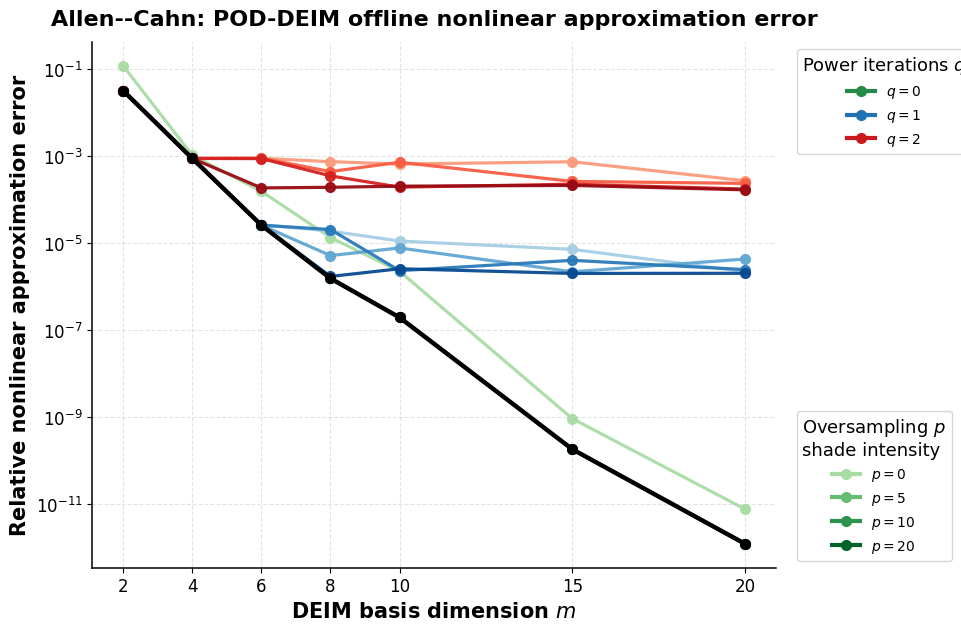

Saved: thesis_figures/allen_cahn_deim_online_error.pdf
Saved: thesis_figures/allen_cahn_deim_online_error.png


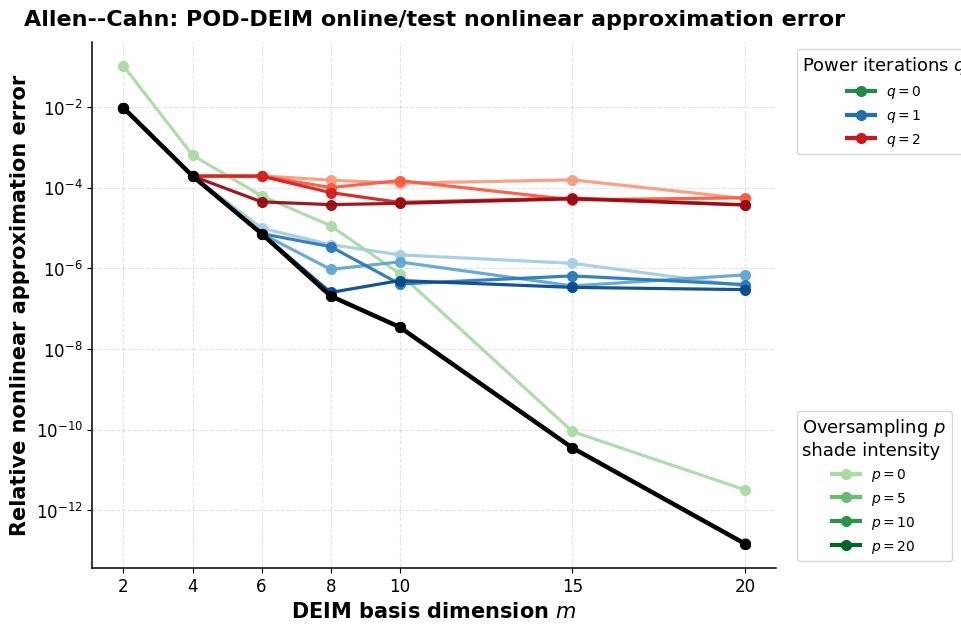

Saved: thesis_figures/allen_cahn_deim_basis_time.pdf
Saved: thesis_figures/allen_cahn_deim_basis_time.png


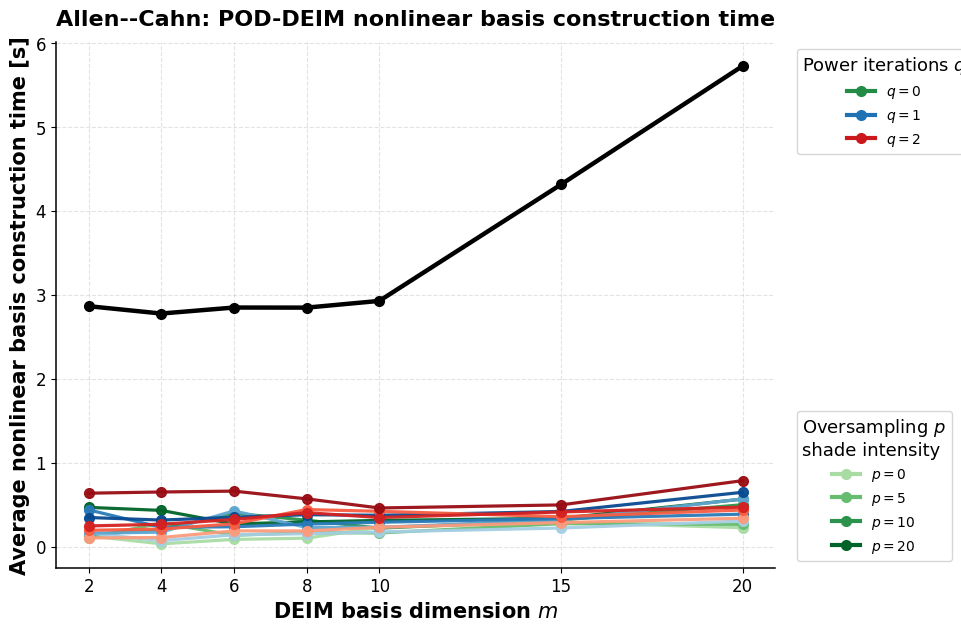

In [7]:
plot_deim_metric(
    ac_deim_results,
    metric="offline_mean_error",
    title="Allen--Cahn: POD-DEIM offline nonlinear approximation error",
    filename="allen_cahn_deim_offline_error",
)

plot_deim_metric(
    ac_deim_results,
    metric="online_mean_error",
    title="Allen--Cahn: POD-DEIM online/test nonlinear approximation error",
    filename="allen_cahn_deim_online_error",
)


plot_deim_time(
    ac_deim_results,
    title="Allen--Cahn: POD-DEIM nonlinear basis construction time",
    filename="allen_cahn_deim_basis_time",
)


# Part B: Nonlinear steady-state elliptic problem

We now study the benchmark nonlinear elliptic problem:

$$
-\nabla^2 u(x,y)+s(u(x,y);\mu)=100\sin(2\pi x)\sin(2\pi y),
$$

where

$$
s(u;\mu)=\frac{\mu_1}{\mu_2}\left(e^{\mu_2u}-1\right),
\qquad
\mu=(\mu_1,\mu_2)\in[0.01,10]^2.
$$

After finite-difference discretization, we solve the nonlinear algebraic system using Newton's method.

## 7. Full-order solver for the nonlinear elliptic problem

In [8]:
@dataclass
class EllipticConfig:
    n: int = 256
    newton_tol: float = 1e-10
    newton_max_iter: int = 30


def elliptic_rhs(X, Y):
    return 100.0 * np.sin(2 * np.pi * X) * np.sin(2 * np.pi * Y)


def nonlinear_s(u, mu1, mu2):
    """
    s(u; mu) = (mu1/mu2)(exp(mu2 u)-1)
    """
    z = np.clip(mu2 * u, -50, 50)
    return (mu1 / mu2) * (np.exp(z) - 1.0)


def nonlinear_s_prime(u, mu1, mu2):
    """
    derivative of s(u; mu) wrt u: mu1 exp(mu2 u)
    """
    z = np.clip(mu2 * u, -50, 50)
    return mu1 * np.exp(z)


def solve_elliptic(mu1, mu2, config, initial_guess=None, verbose=False):
    """
    Solve:
        -Delta u + s(u; mu) = rhs
    with homogeneous Dirichlet BCs.

    Since L approximates Delta, the discrete residual is:
        F(u) = -L u + s(u) - rhs.
    """
    L, h, X, Y = make_laplacian_2d(config.n)
    N = config.n**2
    rhs = elliptic_rhs(X, Y).reshape(-1)

    if initial_guess is None:
        u = np.zeros(N)
    else:
        u = initial_guess.copy()

    t0 = time.perf_counter()
    converged = False

    for it in range(config.newton_max_iter):
        F = -L @ u + nonlinear_s(u, mu1, mu2) - rhs
        res = la.norm(F) / max(la.norm(rhs), 1e-14)

        if verbose:
            print(f"Newton iter {it:02d}, residual={res:.3e}")

        if res < config.newton_tol:
            converged = True
            break

        J = -L + sp.diags(nonlinear_s_prime(u, mu1, mu2), 0, format="csr")
        du = spla.spsolve(J.tocsc(), -F)
        u = u + du

    elapsed = time.perf_counter() - t0

    return {
        "u": u,
        "elapsed": elapsed,
        "converged": converged,
        "iterations": it + 1,
        "grid": (X, Y),
    }


ell_config = EllipticConfig()

test_sol = solve_elliptic(mu1=1.0, mu2=1.0, config=ell_config, verbose=False)
print("Converged:", test_sol["converged"])
print("Newton iterations:", test_sol["iterations"])
print(f"Solve time: {test_sol['elapsed']:.3f} s")

Converged: True
Newton iterations: 4
Solve time: 1.375 s


## 8. Generate parameterized snapshots

We sample a small training grid in the parameter domain:

$$
(\mu_1,\mu_2)\in[0.01,10]^2.
$$

For each parameter pair, the nonlinear PDE is solved using Newton's method.
The resulting solution vectors form the snapshot matrix.

In [9]:
mu1_values = np.linspace(0.01, 10.0, 16)
mu2_values = np.linspace(0.01, 10.0, 16)

ell_snapshots = []
ell_nonlinear_snapshots = []
ell_params = []
ell_solve_times = []

previous_u = None

for mu1 in mu1_values:
    for mu2 in mu2_values:
        sol = solve_elliptic(mu1, mu2, ell_config, initial_guess=previous_u)
        if not sol["converged"]:
            print(f"Warning: Newton did not fully converge for mu=({mu1:.2f},{mu2:.2f})")

        u = sol["u"]
        previous_u = u

        ell_snapshots.append(u)
        ell_nonlinear_snapshots.append(nonlinear_s(u, mu1, mu2))
        ell_params.append((mu1, mu2))
        ell_solve_times.append(sol["elapsed"])

S_ell = np.column_stack(ell_snapshots)
F_ell = np.column_stack(ell_nonlinear_snapshots)

print("Elliptic snapshot matrix shape:", S_ell.shape)
print("Elliptic nonlinear snapshot matrix shape:", F_ell.shape)
print(f"Mean full-order solve time: {np.mean(ell_solve_times):.3f} s")

Elliptic snapshot matrix shape: (65536, 256)
Elliptic nonlinear snapshot matrix shape: (65536, 256)
Mean full-order solve time: 1.662 s


## 10. POD and rSVD-POD comparison for the elliptic problem

We repeat the same reduced-basis analysis:

$$
E_r =
\frac{\|S-\Phi_r\Phi_r^T S\|_F}{\|S\|_F}.
$$

This measures how accurately the reduced basis reconstructs the parameterized solution manifold.

In [10]:
r_values_ell = [2, 4, 6, 8, 10, 15, 20]
oversampling_values_ell = [0, 5, 10, 20]
power_iteration_values_ell = [0, 1, 2]

# Train/test split for the parameterized solution manifold.
# The POD basis is built only on S_ell_train.
split_ell = int(0.7 * S_ell.shape[1])
S_ell_train = S_ell[:, :split_ell]
F_ell_train = F_ell[:, :split_ell]
params_train_ell = ell_params[:split_ell]

S_ell_test = S_ell[:, split_ell:]
F_ell_test = F_ell[:, split_ell:]
params_test_ell = ell_params[split_ell:]

ell_results = []

for r in r_values_ell:
    r_eff = min(r, min(S_ell_train.shape) - 1)

    # -------------------------------------------------------------------------
    # Deterministic POD-SVD baseline
    # -------------------------------------------------------------------------
    Phi, s, build_time, info = pod_basis(
        S_ell_train,
        r_eff,
        method="svd",
        svd_mode=SVD_MODE,
        n_repeats=N_EXPERIMENT_REPEATS,
    )

    offline_err = projection_reconstruction_error(S_ell_train, Phi)
    online_err = projection_reconstruction_error(S_ell_test, Phi)

    ell_results.append({
        "method": "POD-SVD",
        "r": info["r_eff"],
        "p": None,
        "p_eff": None,
        "q": None,
        "offline_error": offline_err,
        "online_error": online_err,
        "error": online_err,
        "time": build_time,
        "time_std": info["time_std"],
    })

    # -------------------------------------------------------------------------
    # Randomized POD bases for every p, q pair
    # -------------------------------------------------------------------------
    for q in power_iteration_values_ell:
        for p in oversampling_values_ell:
            Phi_r, s_r, build_time_r, info = pod_basis(
                S_ell_train,
                r_eff,
                method="rsvd",
                oversampling=p,
                n_iter=q,
                random_state=42,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
                n_repeats=N_EXPERIMENT_REPEATS,
            )

            offline_err_r = projection_reconstruction_error(S_ell_train, Phi_r)
            online_err_r = projection_reconstruction_error(S_ell_test, Phi_r)

            ell_results.append({
                "method": "POD-rSVD",
                "r": info["r_eff"],
                "p": p,
                "p_eff": info["p_eff"],
                "q": q,
                "offline_error": offline_err_r,
                "online_error": online_err_r,
                "error": online_err_r,
                "time": build_time_r,
                "time_std": info["time_std"],
            })


Saved: thesis_figures/elliptic_pod_offline_error.pdf
Saved: thesis_figures/elliptic_pod_offline_error.png


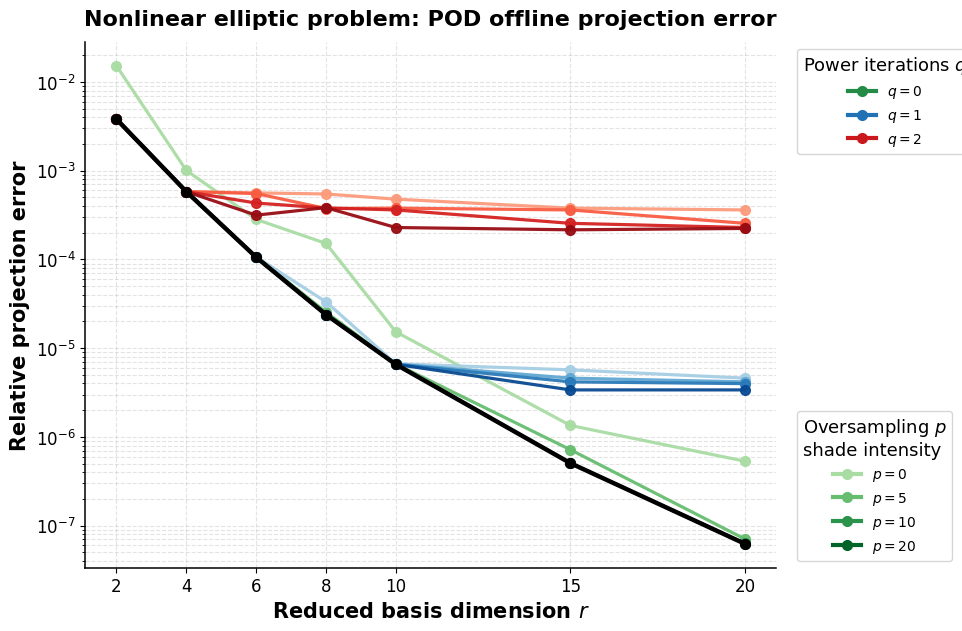

Saved: thesis_figures/elliptic_pod_online_error.pdf
Saved: thesis_figures/elliptic_pod_online_error.png


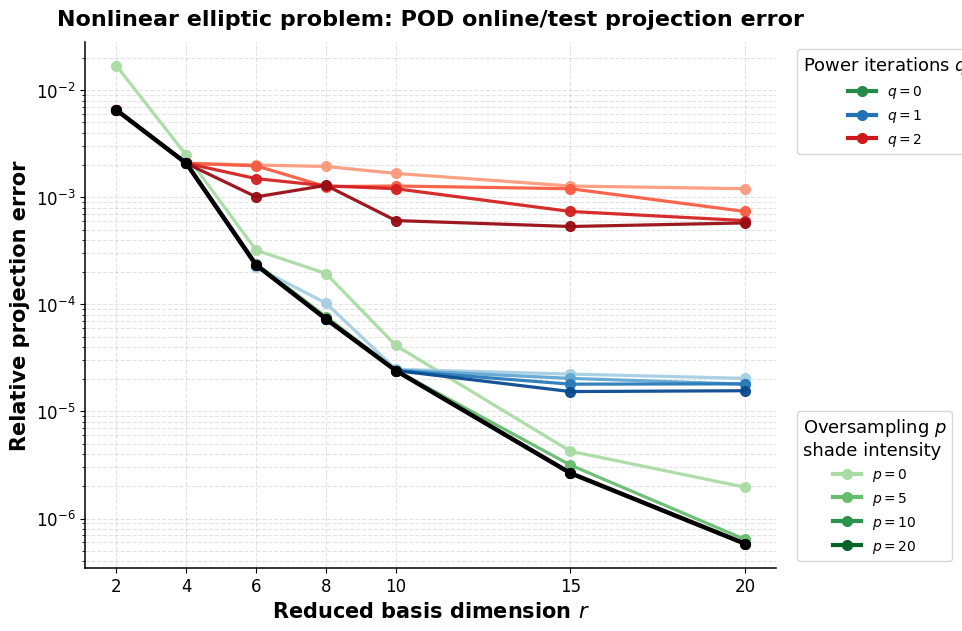

Saved: thesis_figures/elliptic_pod_basis_time.pdf
Saved: thesis_figures/elliptic_pod_basis_time.png


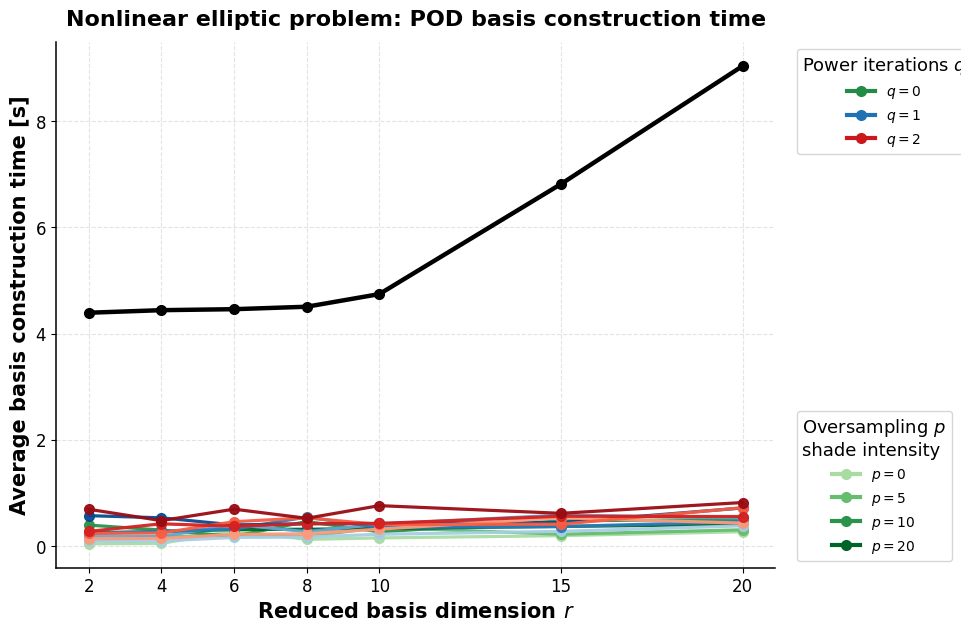

Each reported POD basis time is averaged over 10 runs.


In [11]:
plot_pod_metric(
    ell_results,
    metric="offline_error",
    title="Nonlinear elliptic problem: POD offline projection error",
    filename="elliptic_pod_offline_error",
)

plot_pod_metric(
    ell_results,
    metric="online_error",
    title="Nonlinear elliptic problem: POD online/test projection error",
    filename="elliptic_pod_online_error",
)


plot_pod_time(
    ell_results,
    title="Nonlinear elliptic problem: POD basis construction time",
    filename="elliptic_pod_basis_time",
)

print("Each reported POD basis time is averaged over", N_EXPERIMENT_REPEATS, "runs.")


## 11. POD-DEIM and POD-rSVD-DEIM analysis for the elliptic nonlinear term

The nonlinear term is

$$
s(u;\mu)=\frac{\mu_1}{\mu_2}\left(e^{\mu_2u}-1\right).
$$

For each test snapshot, we compare the exact nonlinear vector with its DEIM approximation.
As for Allen-Cahn, we compute the nonlinear DEIM basis using either classical SVD or randomized SVD.


In [13]:
m_deim_values_ell = [2, 4, 6, 8, 10, 15, 20]
rsvd_deim_oversampling_values_ell = [0, 5, 10, 20]
rsvd_deim_power_iteration_values_ell = [0, 1, 2]

# For the elliptic problem, the nonlinear function depends on the parameter mu.
def make_elliptic_nonlinear_function(mu1, mu2):
    return lambda u: nonlinear_s(u, mu1, mu2)


def evaluate_elliptic_deim_on_snapshots(S_eval, params_eval, U_f, indices, n_repeats=10):
    """Evaluate DEIM error for elliptic snapshots with their own parameters."""
    errors = []
    full_times = []
    deim_times = []

    for j in range(S_eval.shape[1]):
        u = S_eval[:, j]
        mu1, mu2 = params_eval[j]
        nonlinear_function = make_elliptic_nonlinear_function(mu1, mu2)
        f_true = nonlinear_function(u)

        _, full_t, _ = time_function(lambda: nonlinear_function(u), n_repeats=n_repeats)
        f_deim, deim_t, _ = time_function(lambda: deim_approximation(f_true, U_f, indices), n_repeats=n_repeats)

        denom = la.norm(f_true)
        errors.append(la.norm(f_true - f_deim) / denom if denom > 0 else 0.0)
        full_times.append(full_t)
        deim_times.append(deim_t)

    return {
        "mean_error": float(np.mean(errors)),
        "std_error": float(np.std(errors)),
        "full_time": float(np.mean(full_times)),
        "deim_time": float(np.mean(deim_times)),
        "speedup": float(np.mean(full_times) / np.mean(deim_times)) if np.mean(deim_times) > 0 else np.inf,
    }


def elliptic_deim_analysis_train_test(
    F_train,
    S_train,
    params_train,
    S_test,
    params_test,
    m_values,
    basis_method="svd",
    oversampling=10,
    n_iter=1,
    n_repeats=10,
    n_basis_repeats=None,
    svd_mode=None,
    rsvd_inner_svd_mode=None,
):
    """Build the nonlinear DEIM basis on F_train and evaluate train/test errors."""
    results = []
    if n_basis_repeats is None:
        n_basis_repeats = N_EXPERIMENT_REPEATS

    for m in m_values:
        U_f, sf, build_time, info = pod_basis(
            F_train,
            m,
            method=basis_method,
            oversampling=oversampling,
            n_iter=n_iter,
            random_state=42,
            svd_mode=svd_mode,
            rsvd_inner_svd_mode=rsvd_inner_svd_mode,
            n_repeats=n_basis_repeats,
        )

        m_eff = info["r_eff"]
        indices = deim(U_f)

        offline = evaluate_elliptic_deim_on_snapshots(S_train, params_train, U_f, indices, n_repeats=n_repeats)
        online = evaluate_elliptic_deim_on_snapshots(S_test, params_test, U_f, indices, n_repeats=n_repeats)

        label = "POD-DEIM" if basis_method == "svd" else f"p={oversampling}, q={n_iter}"
        results.append({
            "method": label,
            "basis_method": basis_method,
            "m": m_eff,
            "p": None if basis_method == "svd" else oversampling,
            "p_eff": info["p_eff"],
            "q": None if basis_method == "svd" else n_iter,
            "basis_time": float(build_time),
            "basis_time_std": info["time_std"],
            "offline_mean_error": offline["mean_error"],
            "offline_std_error": offline["std_error"],
            "online_mean_error": online["mean_error"],
            "online_std_error": online["std_error"],
            "mean_error": online["mean_error"],
            "std_error": online["std_error"],
            "full_time": online["full_time"],
            "deim_time": online["deim_time"],
            "speedup": online["speedup"],
            "offline_full_time": offline["full_time"],
            "offline_deim_time": offline["deim_time"],
            "offline_speedup": offline["speedup"],
            "n_deim_points": int(len(indices)),
        })

    return results


ell_deim_svd_results = elliptic_deim_analysis_train_test(
    F_train=F_ell_train,
    S_train=S_ell_train,
    params_train=params_train_ell,
    S_test=S_ell_test,
    params_test=params_test_ell,
    m_values=m_deim_values_ell,
    basis_method="svd",
    n_repeats=10,
    n_basis_repeats=N_EXPERIMENT_REPEATS,
    svd_mode=SVD_MODE,
)

ell_deim_rsvd_results = []
for q in rsvd_deim_power_iteration_values_ell:
    for p in rsvd_deim_oversampling_values_ell:
        ell_deim_rsvd_results.extend(
            elliptic_deim_analysis_train_test(
                F_train=F_ell_train,
                S_train=S_ell_train,
                params_train=params_train_ell,
                S_test=S_ell_test,
                params_test=params_test_ell,
                m_values=m_deim_values_ell,
                basis_method="rsvd",
                oversampling=p,
                n_iter=q,
                n_repeats=10,
                n_basis_repeats=N_EXPERIMENT_REPEATS,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
            )
        )

ell_deim_results = ell_deim_svd_results + ell_deim_rsvd_results

for row in ell_deim_results[:12]:
    print(row)


{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 2, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 6.489784833700105, 'basis_time_std': 2.6519190342949615, 'offline_mean_error': 0.13459799606627385, 'offline_std_error': 0.1281925529509514, 'online_mean_error': 0.09690180324495361, 'online_std_error': 0.09107692879127899, 'mean_error': 0.09690180324495361, 'std_error': 0.09107692879127899, 'full_time': 0.0014263107662384742, 'deim_time': 0.00021953468831152465, 'speedup': 6.496972197006548, 'offline_full_time': 0.0014273612754082965, 'offline_deim_time': 0.00022029070393204698, 'offline_speedup': 6.4794439798448975, 'n_deim_points': 2}
{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 4, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 4.742107152500102, 'basis_time_std': 0.4771405497874364, 'offline_mean_error': 0.02433029718606406, 'offline_std_error': 0.02854001899849566, 'online_mean_error': 0.023389033384567156, 'online_std_error': 0.010187349569480168, 'mean_error': 0.023

Saved: thesis_figures/elliptic_deim_offline_error.pdf
Saved: thesis_figures/elliptic_deim_offline_error.png


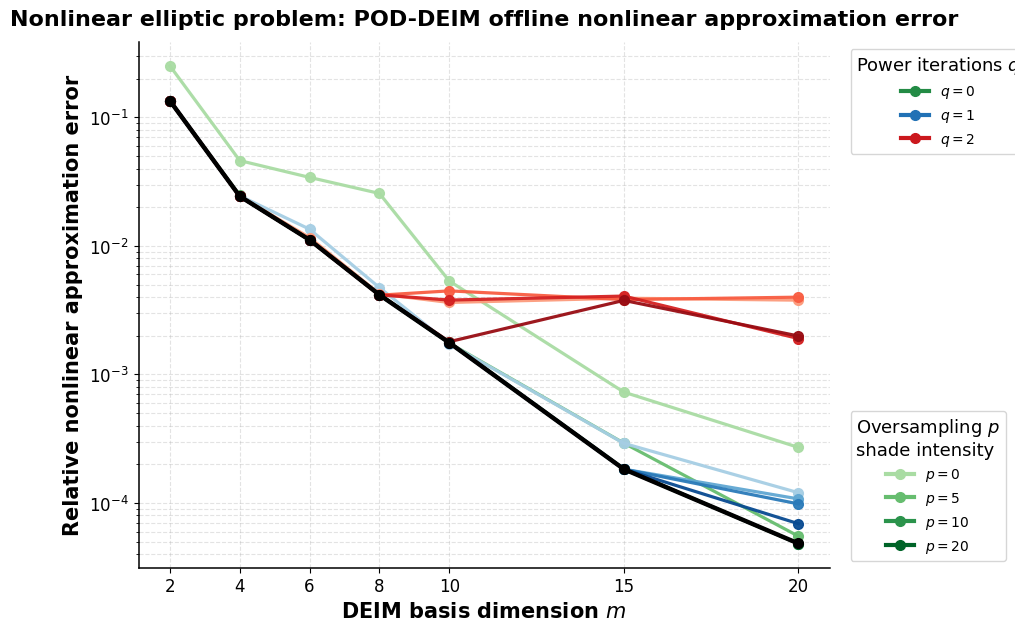

Saved: thesis_figures/elliptic_deim_online_error.pdf
Saved: thesis_figures/elliptic_deim_online_error.png


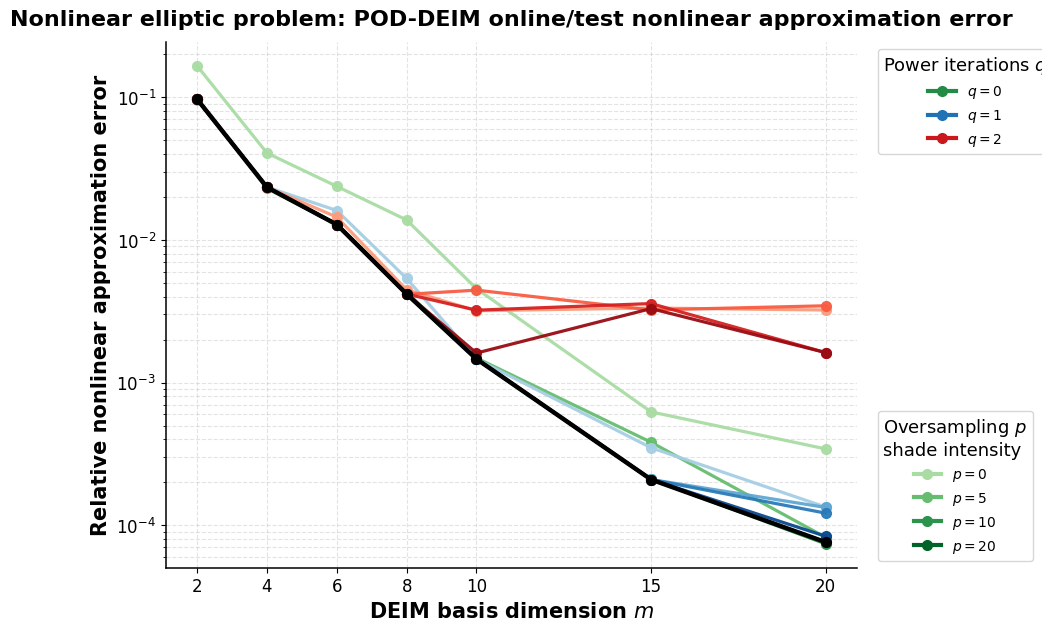

Saved: thesis_figures/elliptic_deim_basis_time.pdf
Saved: thesis_figures/elliptic_deim_basis_time.png


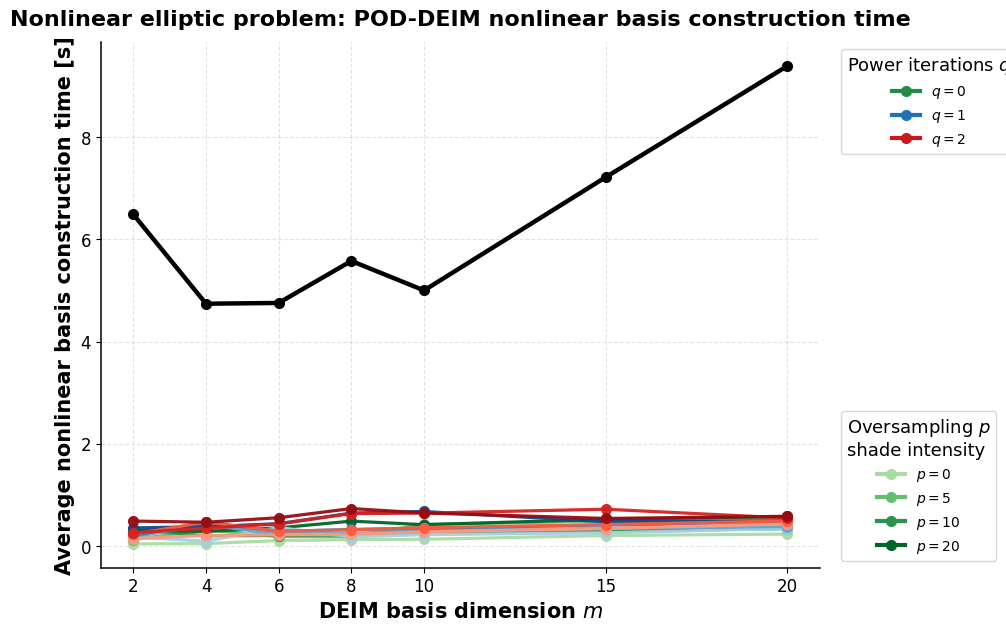

In [14]:
plot_deim_metric(
    ell_deim_results,
    metric="offline_mean_error",
    title="Nonlinear elliptic problem: POD-DEIM offline nonlinear approximation error",
    filename="elliptic_deim_offline_error",
)

plot_deim_metric(
    ell_deim_results,
    metric="online_mean_error",
    title="Nonlinear elliptic problem: POD-DEIM online/test nonlinear approximation error",
    filename="elliptic_deim_online_error",
)


plot_deim_time(
    ell_deim_results,
    title="Nonlinear elliptic problem: POD-DEIM nonlinear basis construction time",
    filename="elliptic_deim_basis_time",
)


# 12. Final comparison tables

The following tables summarize:

- POD-SVD and POD-rSVD projection error;
- POD basis construction time;
- POD-DEIM and POD-rSVD-DEIM nonlinear approximation error;
- DEIM nonlinear evaluation time;
- nonlinear basis construction time.

These quantities can be exported and used directly in the report.


In [15]:
import pandas as pd

ac_pod_df = pd.DataFrame(ac_results)
ell_pod_df = pd.DataFrame(ell_results)

ac_deim_df = pd.DataFrame(ac_deim_results)
ell_deim_df = pd.DataFrame(ell_deim_results)

print("Allen-Cahn POD/rSVD-POD results")
display(ac_pod_df)

print("Allen-Cahn DEIM results")
display(ac_deim_df)

print("Elliptic POD/rSVD-POD results")
display(ell_pod_df)

print("Elliptic DEIM results")
display(ell_deim_df)

Allen-Cahn POD/rSVD-POD results


,method,r,p,p_eff,q,offline_error,online_error,error,time,time_std
0,POD-SVD,2,NaN,NaN,NaN,0.002897,5.157092e-04,5.157092e-04,2.603430,0.397482
1,POD-rSVD,2,0.0,0.0,0.0,0.007486,5.994594e-03,5.994594e-03,0.033986,0.007279
2,POD-rSVD,2,5.0,5.0,0.0,0.002897,5.157092e-04,5.157092e-04,0.102770,0.042593
3,POD-rSVD,2,10.0,10.0,0.0,0.002897,5.157092e-04,5.157092e-04,0.364718,0.255786
4,POD-rSVD,2,20.0,20.0,0.0,0.002897,5.157092e-04,5.157092e-04,0.245180,0.053270
...,...,...,...,...,...,...,...,...,...,...
86,POD-rSVD,20,20.0,20.0,1.0,0.000002,2.358938e-07,2.358938e-07,0.466420,0.036320
87,POD-rSVD,20,0.0,0.0,2.0,0.000353,5.451090e-05,5.451090e-05,0.540703,0.458927
88,POD-rSVD,20,5.0,5.0,2.0,0.000354,5.466934e-05,5.466934e-05,0.458581,0.108751
89,POD-rSVD,20,10.0,10.0,2.0,0.000354,5.463738e-05,5.463738e-05,0.466994,0.018583


Allen-Cahn DEIM results


,method,basis_method,m,p,p_eff,q,basis_time,basis_time_std,offline_mean_error,offline_std_error,...,online_std_error,mean_error,std_error,full_time,deim_time,speedup,offline_full_time,offline_deim_time,offline_speedup,n_deim_points
0,POD-DEIM,svd,2,NaN,NaN,NaN,2.864523,0.513241,3.227850e-02,6.047303e-02,...,1.734723e-18,9.580463e-03,1.734723e-18,0.006642,0.000274,24.237525,0.006799,0.000298,22.828079,2
1,POD-DEIM,svd,4,NaN,NaN,NaN,2.776981,0.490659,8.953354e-04,1.749104e-03,...,5.421011e-20,1.941081e-04,5.421011e-20,0.006762,0.000356,19.003077,0.007417,0.000393,18.864354,4
2,POD-DEIM,svd,6,NaN,NaN,NaN,2.848460,0.437634,2.614277e-05,4.084147e-05,...,8.470329e-22,7.237663e-06,8.470329e-22,0.007079,0.000445,15.914234,0.007557,0.000488,15.474658,6
3,POD-DEIM,svd,8,NaN,NaN,NaN,2.847346,0.502509,1.561179e-06,4.059253e-06,...,5.293956e-23,2.050135e-07,5.293956e-23,0.008098,0.000563,14.385337,0.009875,0.001019,9.690858,8
4,POD-DEIM,svd,10,NaN,NaN,NaN,2.927499,0.490307,1.977065e-07,3.496974e-07,...,6.617445e-24,3.471669e-08,6.617445e-24,0.007749,0.000613,12.632819,0.009114,0.001112,8.198676,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,"p=20, q=2",rsvd,6,20.0,20.0,2.0,0.662410,0.332168,1.882019e-04,3.256776e-04,...,1.355253e-20,4.442159e-05,1.355253e-20,0.006512,0.000690,9.440875,0.006409,0.000623,10.279732,6
87,"p=20, q=2",rsvd,8,20.0,20.0,2.0,0.570181,0.251722,1.945710e-04,3.863619e-04,...,1.355253e-20,3.798296e-05,1.355253e-20,0.011132,0.001565,7.113449,0.006631,0.000543,12.215509,8
88,"p=20, q=2",rsvd,10,20.0,20.0,2.0,0.461632,0.028738,2.064836e-04,4.067517e-04,...,0.000000e+00,4.081207e-05,0.000000e+00,0.007910,0.000889,8.893907,0.009341,0.001317,7.092666,10
89,"p=20, q=2",rsvd,15,20.0,20.0,2.0,0.498191,0.034649,2.149399e-04,3.734277e-04,...,6.776264e-21,5.271708e-05,6.776264e-21,0.007398,0.001226,6.034802,0.009043,0.001785,5.065770,15


Elliptic POD/rSVD-POD results


,method,r,p,p_eff,q,offline_error,online_error,error,time,time_std
0,POD-SVD,2,NaN,NaN,NaN,0.003815,0.006531,0.006531,4.391351,0.303656
1,POD-rSVD,2,0.0,0.0,0.0,0.015198,0.016882,0.016882,0.039296,0.001316
2,POD-rSVD,2,5.0,5.0,0.0,0.003816,0.006527,0.006527,0.104845,0.021502
3,POD-rSVD,2,10.0,10.0,0.0,0.003815,0.006531,0.006531,0.392154,0.227796
4,POD-rSVD,2,20.0,20.0,0.0,0.003815,0.006531,0.006531,0.251568,0.042348
...,...,...,...,...,...,...,...,...,...,...
86,POD-rSVD,20,20.0,20.0,1.0,0.000003,0.000016,0.000016,0.714408,0.376173
87,POD-rSVD,20,0.0,0.0,2.0,0.000362,0.001203,0.001203,0.428926,0.066722
88,POD-rSVD,20,5.0,5.0,2.0,0.000256,0.000738,0.000738,0.719495,0.521723
89,POD-rSVD,20,10.0,10.0,2.0,0.000229,0.000607,0.000607,0.552943,0.039955


Elliptic DEIM results


,method,basis_method,m,p,p_eff,q,basis_time,basis_time_std,offline_mean_error,offline_std_error,...,online_std_error,mean_error,std_error,full_time,deim_time,speedup,offline_full_time,offline_deim_time,offline_speedup,n_deim_points
0,POD-DEIM,svd,2,NaN,NaN,NaN,6.489785,2.651919,0.134598,0.128193,...,0.091077,0.096902,0.091077,0.001426,0.000220,6.496972,0.001427,0.000220,6.479444,2
1,POD-DEIM,svd,4,NaN,NaN,NaN,4.742107,0.477141,0.024330,0.028540,...,0.010187,0.023389,0.010187,0.001438,0.000299,4.815434,0.002016,0.000436,4.624533,4
2,POD-DEIM,svd,6,NaN,NaN,NaN,4.756976,0.377641,0.011141,0.011952,...,0.005949,0.012814,0.005949,0.001428,0.000369,3.868387,0.001475,0.000375,3.932440,6
3,POD-DEIM,svd,8,NaN,NaN,NaN,5.578805,1.540998,0.004164,0.004159,...,0.002524,0.004176,0.002524,0.002208,0.000461,4.784811,0.002519,0.000739,3.408210,8
4,POD-DEIM,svd,10,NaN,NaN,NaN,5.001871,0.417345,0.001766,0.003091,...,0.000564,0.001463,0.000564,0.003400,0.001711,1.987667,0.002292,0.000598,3.829229,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,"p=20, q=2",rsvd,6,20.0,20.0,2.0,0.552898,0.172633,0.011141,0.011952,...,0.005949,0.012814,0.005949,0.001393,0.000559,2.490885,0.001410,0.000557,2.529214,6
87,"p=20, q=2",rsvd,8,20.0,20.0,2.0,0.732754,0.461867,0.004169,0.004169,...,0.002524,0.004180,0.002524,0.002786,0.001136,2.451513,0.002198,0.000491,4.478222,8
88,"p=20, q=2",rsvd,10,20.0,20.0,2.0,0.645581,0.275684,0.001798,0.002977,...,0.000691,0.001610,0.000691,0.003026,0.001676,1.806030,0.002362,0.000891,2.651133,10
89,"p=20, q=2",rsvd,15,20.0,20.0,2.0,0.539068,0.023653,0.003770,0.004838,...,0.003284,0.003300,0.003284,0.002246,0.001018,2.206841,0.002618,0.001553,1.685431,15


# 13. Save figures and tables

Run this cell if you want to export the numerical results as CSV files for your report.

In [16]:
ac_pod_df.to_csv("allen_cahn_pod_svd_rsvd_results.csv", index=False)
ac_deim_df.to_csv("allen_cahn_pod_deim_rsvd_deim_results.csv", index=False)
ell_pod_df.to_csv("elliptic_pod_svd_rsvd_results.csv", index=False)
ell_deim_df.to_csv("elliptic_pod_deim_rsvd_deim_results.csv", index=False)

print("CSV files exported.")
print(f"Figures are stored in: {FIGURE_DIR}/")


CSV files exported.
Figures are stored in: thesis_figures/


# 14. Download all generated figures as a ZIP file

This cell compresses all exported PDF/PNG figures into a single ZIP file and downloads it from Colab, as in the original notebook.


In [17]:
# Create a ZIP archive containing all thesis figures.
zip_name = "thesis_figures_offline_online_pdf_png.zip"

with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(FIGURE_DIR):
        for file in files:
            if file.endswith((".pdf", ".png")):
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, FIGURE_DIR)
                zf.write(full_path, arcname)

print(f"Created {zip_name}")

# In Google Colab this will trigger a browser download.
try:
    from google.colab import files
    files.download(zip_name)
except Exception:
    print("Not running in Colab. Download the ZIP manually from the file browser.")


Created thesis_figures_offline_online_pdf_png.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>